# K-Means

This notebook is a hands-on practice of K-Means clustering algorithm

Datasets used:
 - https://www.kaggle.com/datasets/himanshunakrani/iris-dataset
 - https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python



In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

iris_df = pd.read_csv("./data/iris.csv")
mall_df = pd.read_csv("./data/Mall_Customers.csv", index_col="CustomerID")

mall_df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


# 1. K-Means from scratch

We implement K-Means step by step to understand how the algorithm works internally.

**Steps**

1. **Initialize centroids**
   - Randomly pick `k` points from the dataset.

2. **Assign clusters**
   - Compute distance from each point to each centroid.
   - Assign the point to the nearest centroid.

3. **Recompute centroids**
   - For each cluster, compute the mean of its points.

4. **Measure inertia (SSE)**
   - Sum of squared distances from points to their centroids.

5. **Repeat**
   - Reassign points and recompute centroids
   - Stop when centroids move less than a small tolerance.

**Key idea**

K-Means iteratively minimizes **within-cluster variance (SSE)** using simple distance-based updates.

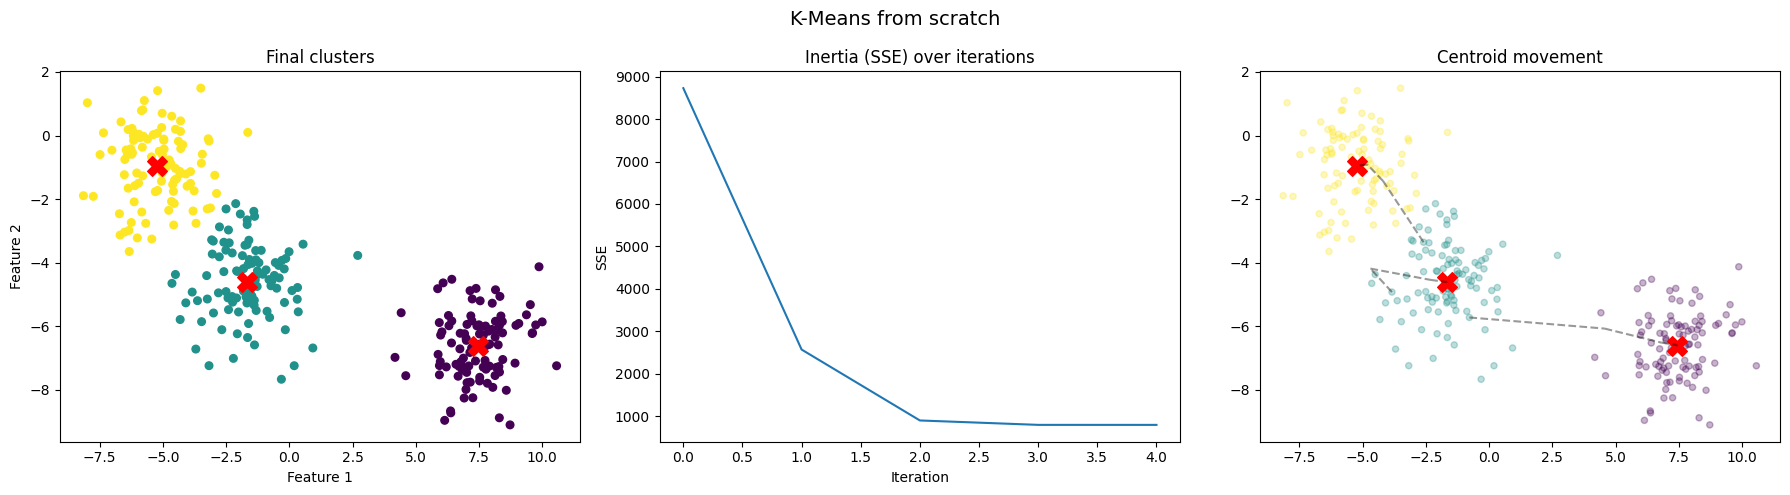

In [2]:
from mlpeople.models.clustering.kmeans import kmeans_from_scratch
from mlpeople.models.clustering.visualization import plot_kmeans_result
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=33)

centroids, labels, history = kmeans_from_scratch(X, k=3, random_state=33)
plot_kmeans_result(X, centroids, labels, history)

# 2. Iris dataset - easy win

In [3]:
# Step 1 — Prepare data (2 features only for easy visualization) 
features = ["petal_length", "petal_width"]

X = iris_df[features].values
y = iris_df["species"].values  # only for comparison later

In [4]:
# Step 2 (optional) — scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Step 3 — Run K-Means from scratch
from mlpeople.models.clustering.kmeans import kmeans_from_scratch

centroids, labels, history = kmeans_from_scratch(
    X_scaled,
    k=3,
    random_state=42
)

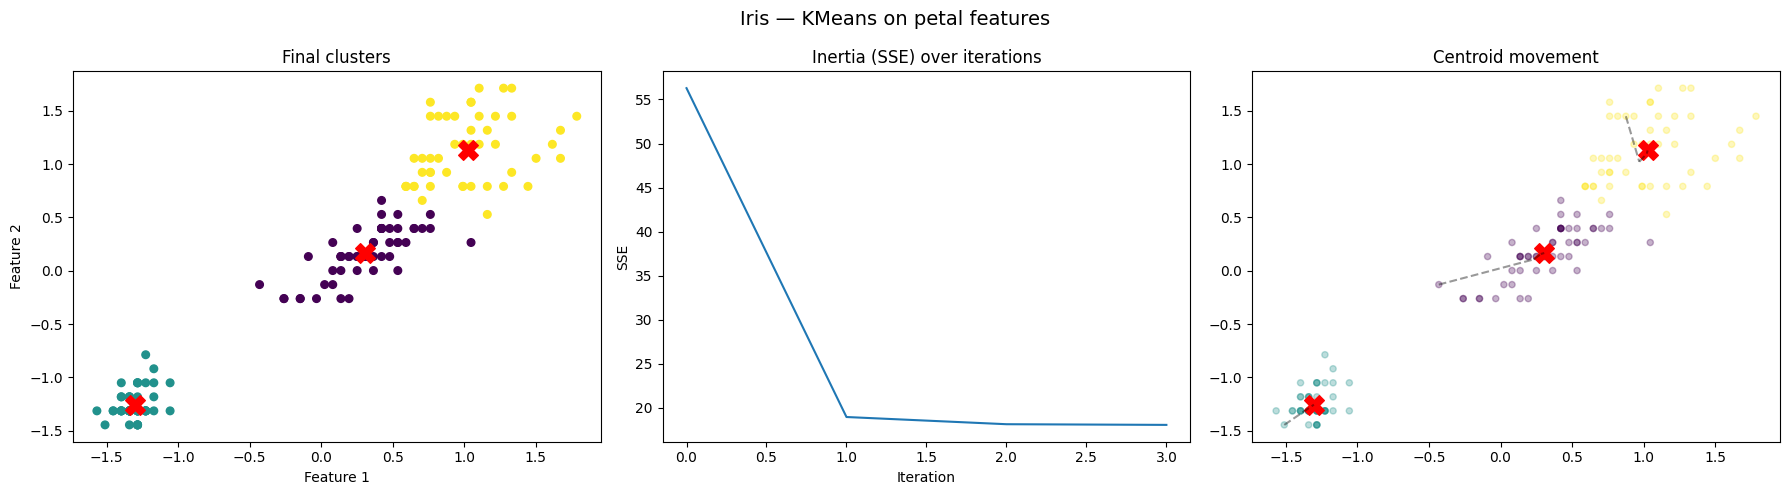

In [6]:
# Step 4 — Visualize clusters
from mlpeople.models.clustering.visualization import plot_kmeans_result

plot_kmeans_result(
    X_scaled,
    centroids,
    labels,
    history,
    title="Iris — KMeans on petal features"
)

In [7]:
# Step 5 — Compare clusters vs real species
import pandas as pd

comparison = pd.DataFrame({
    "cluster": labels,
    "species": y
})

pd.crosstab(comparison["cluster"], comparison["species"])

species,setosa,versicolor,virginica
cluster,,,
0,0,48,4
1,50,0,0
2,0,2,46


In [8]:
def cluster_purity(labels, true_labels):
    df = pd.DataFrame({"cluster": labels, "true": true_labels})
    total = 0
    for _, group in df.groupby("cluster"):
        total += group["true"].value_counts().max()
    return total / len(df)

cluster_purity(labels, y)

np.float64(0.96)

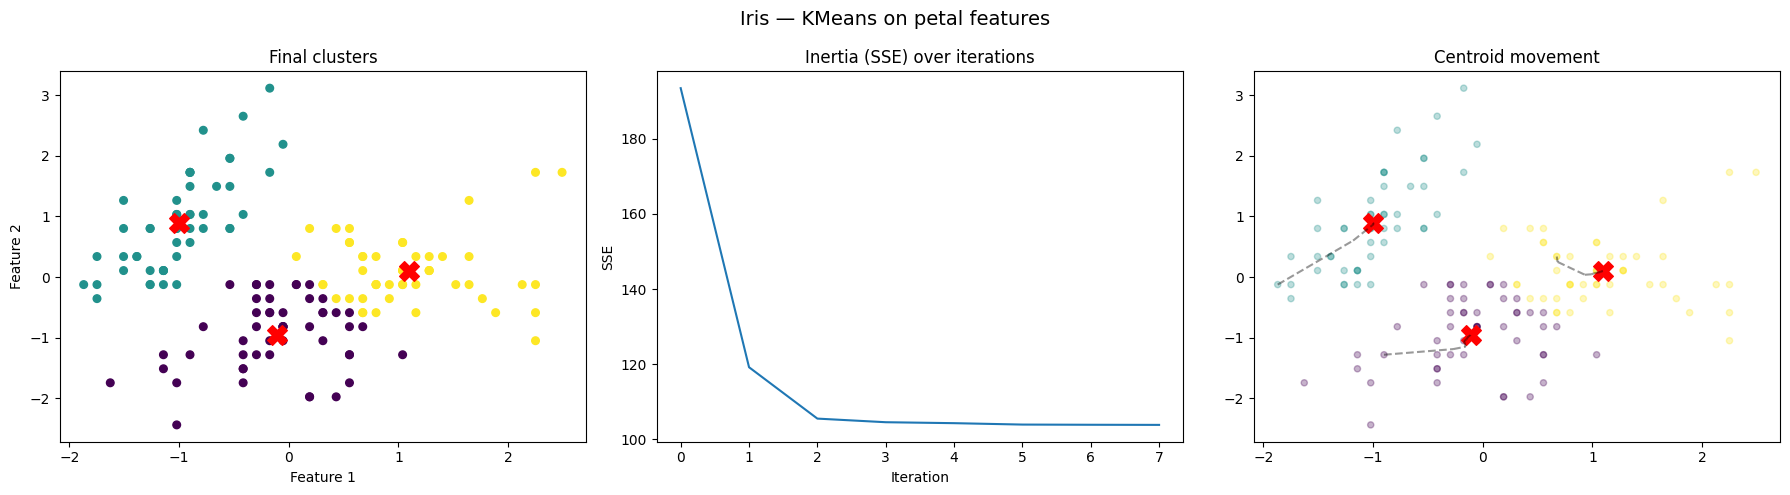

species,setosa,versicolor,virginica
cluster,,,
0,1,34,16
1,49,0,0
2,0,16,34


np.float64(0.78)

In [9]:
# same with 2 other features
features = ["sepal_length", "sepal_width"]

X = iris_df[features].values
y = iris_df["species"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

centroids, labels, history = kmeans_from_scratch(
    X_scaled,
    k=3,
    random_state=42
)

plot_kmeans_result(
    X_scaled,
    centroids,
    labels,
    history,
    title="Iris — KMeans on petal features"
)

comparison = pd.DataFrame({
    "cluster": labels,
    "species": y
})

display(pd.crosstab(comparison["cluster"], comparison["species"]))

cluster_purity(labels, y)

# 3. Mall Customers - real segmentation

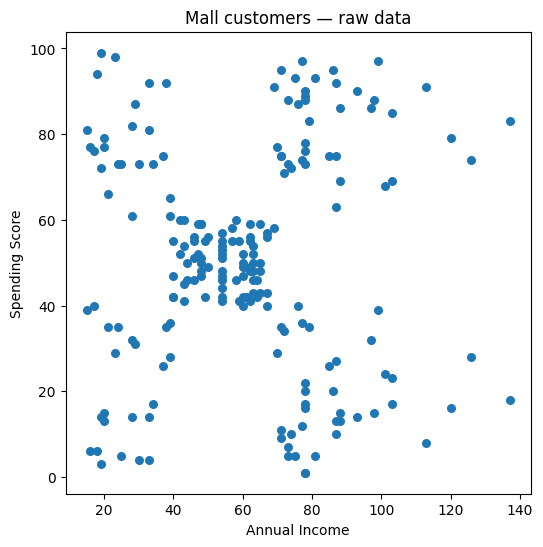

In [10]:
# Step 1 — Select features
features = ["Annual Income (k$)", "Spending Score (1-100)"]

X = mall_df[features].values

# Step 2 — Visualize raw data first
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Mall customers — raw data")
plt.show()

In [11]:
# Step 3 — Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4 — Run K-Means for multiple K
inertias = []

for k in range(2, 11):
    centroids, labels, history = kmeans_from_scratch(
        X_scaled, k=k, random_state=42
    )
    inertias.append(history["inertia"][-1])

## Elbow method

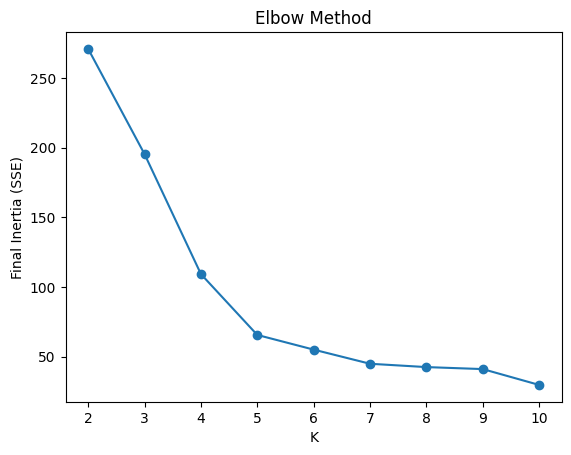

In [12]:
# Step 5 — Elbow method
plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Final Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

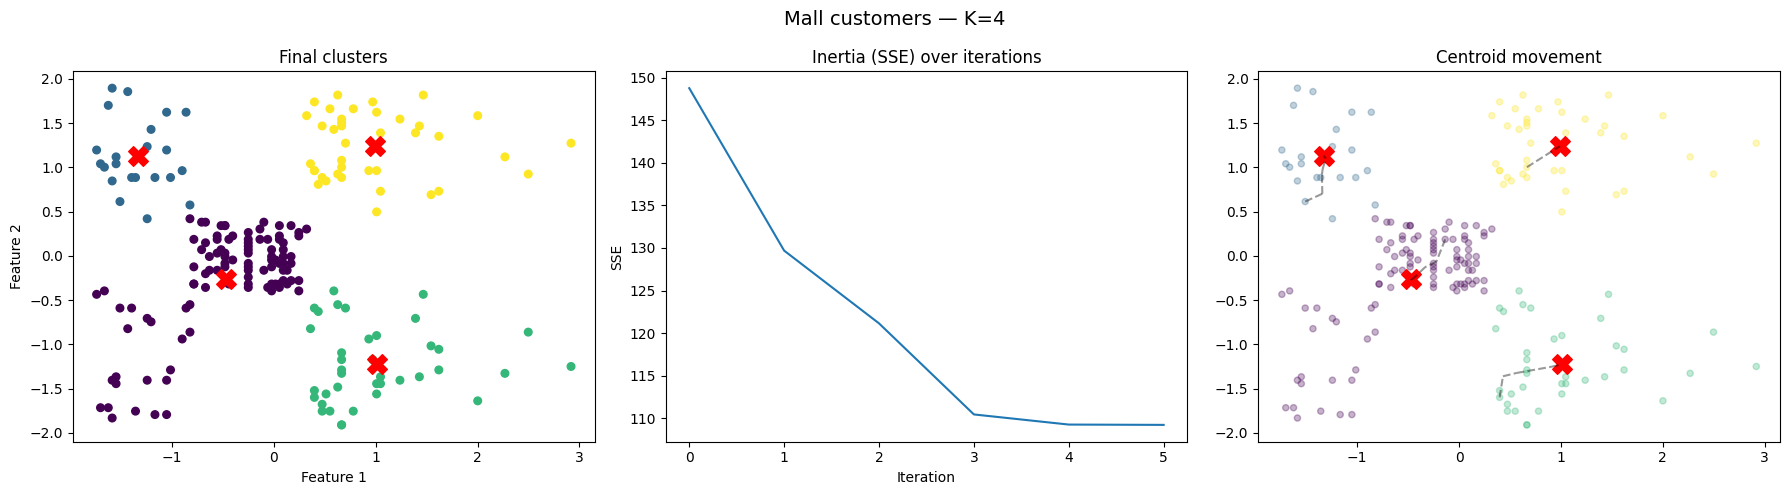

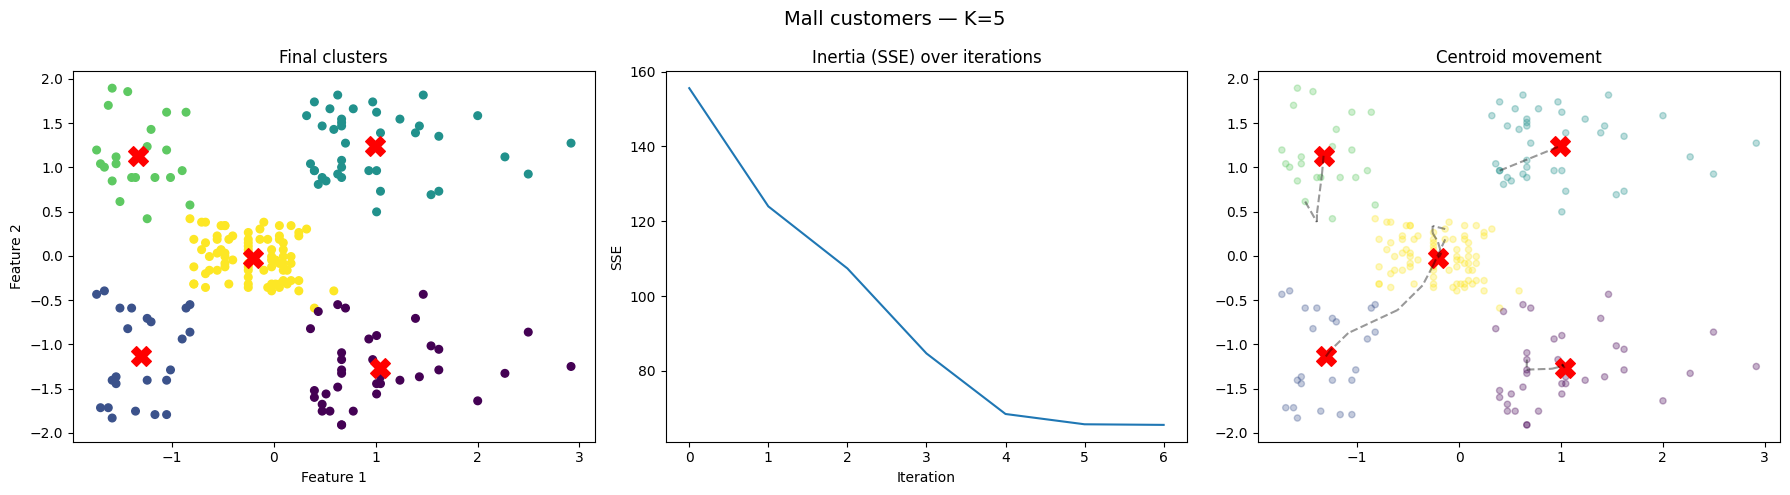

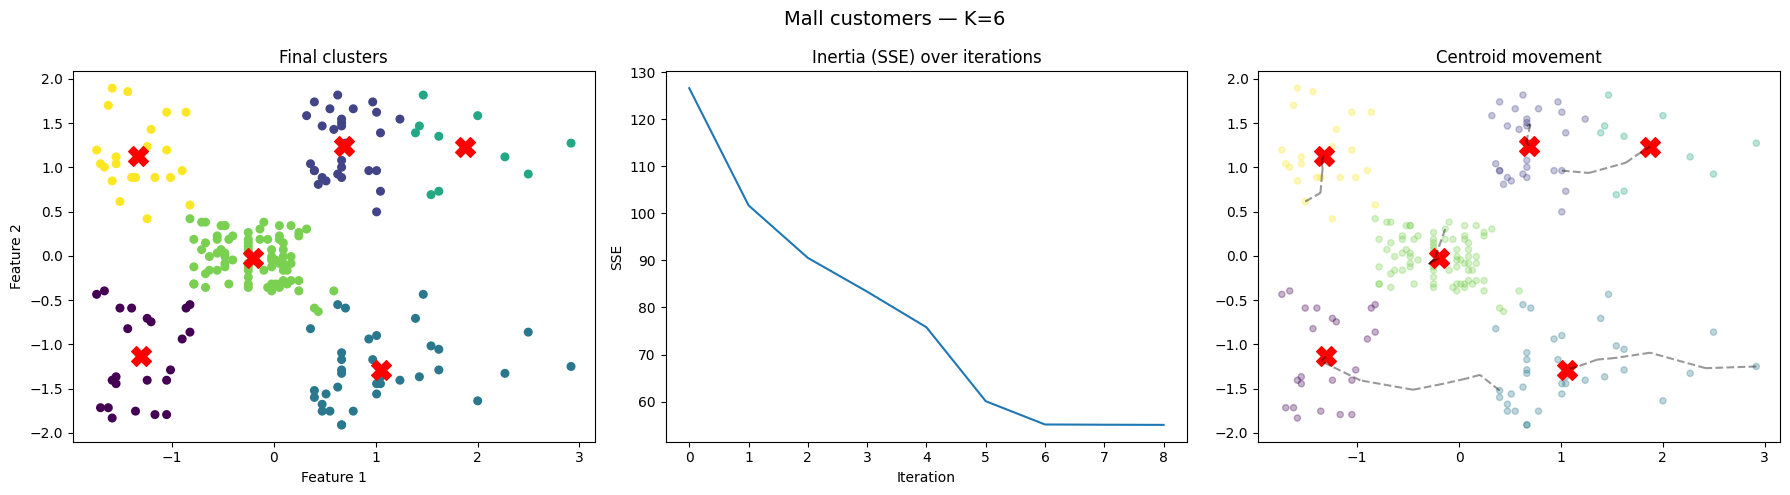

In [13]:
# Step 6 — Visually inspect different K
for k in [4, 5, 6]:
    centroids, labels, history = kmeans_from_scratch(
        X_scaled, k=k, random_state=42
    )
    
    plot_kmeans_result(
        X_scaled,
        centroids,
        labels,
        history,
        title=f"Mall customers — K={k}"
    )

## Interpret clusters

| Cluster | Income level | Spending level | What we actually know            | Potential Interpretation             |
| ------- | ------------ | -------------- | -------------------------------- | ------------------------------------ |
| C0      | Low          | Low            | Low income, low spending score   | Low value customers        |
| C1      | Low          | High           | Low income, high spending score  | Impulsive / young shoppers |
| C2      | High         | Low            | High income, low spending score  | Rich but careful           |
| C3      | High         | High           | High income, high spending score | Premium customers          |
| C4      | Mid          | Mid            | Moderate income and spending     | Average shoppers           |



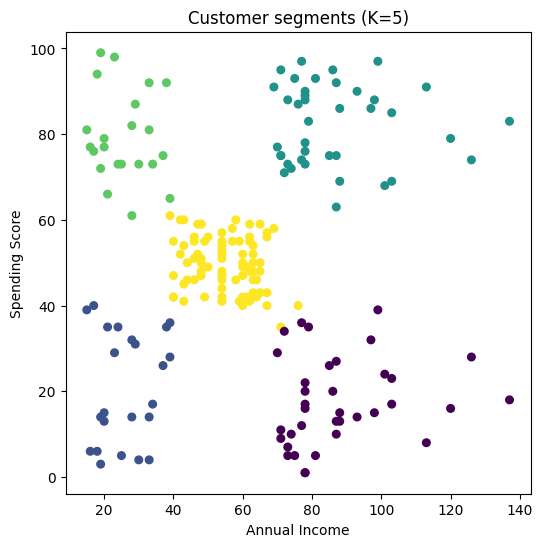

In [14]:
# Step 7 — Show clusters on original (unscaled) axes
centroids, labels, _ = kmeans_from_scratch(X_scaled, k=5, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer segments (K=5)")
plt.show()

# 4. Scaling effect

K-Means uses only **distance**.

We added `Income ($) = Income (k$) × 1000`.  
Same customers, different units.

- **Without scaling** → clusters follow the largest-scale feature
- **With scaling** → meaningful structure appears

**Takeaway:** if clusters look wrong, check **feature scaling** first.

In [ ]:
# Add a fake feature that is the same as income but expressed in dollars instead of thousands
X_bad = mall_df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()
X_bad["Income ($)"] = X_bad["Annual Income (k$)"] * 1000  # explode the scale

X_bad = X_bad.values

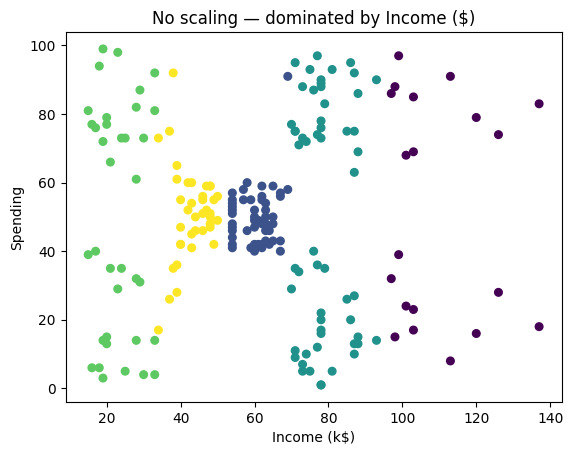

In [19]:
# Run K-Means WITHOUT scaling
centroids_bad, labels_bad, history_bad = kmeans_from_scratch(
    X_bad, k=5, random_state=42
)

plt.scatter(X_bad[:, 0], X_bad[:, 1], c=labels_bad, s=30)
plt.title("No scaling — dominated by Income ($)")
plt.xlabel("Income (k$)")
plt.ylabel("Spending")
plt.show()

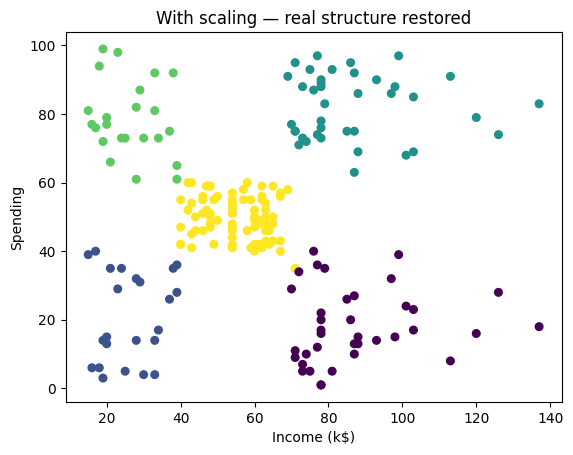

In [ ]:
# with scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_bad_scaled = scaler.fit_transform(X_bad)

centroids_fix, labels_fix, history_fix = kmeans_from_scratch(
    X_bad_scaled, k=5, random_state=42
)

plt.scatter(X_bad[:, 0], X_bad[:, 1], c=labels_fix, s=30)
plt.title("With scaling — real structure restored")
plt.xlabel("Income (k$)")
plt.ylabel("Spending")
plt.show()

# 5. Initialization problem

K-Means can converge to different results depending on the **initial centroid positions**.

On simple, well-separated data this effect may be small.  
On more complex data (e.g., Mall Customers with 3 features), different random seeds lead to **different final SSE and cluster shapes**.

**Takeaway:** K-Means may get stuck in a **local minimum**.  
This is why smarter initialization like *k-means++* is important.

In [26]:
from sklearn.preprocessing import StandardScaler

# Use 3 features (harder geometry)
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Age"
]

X = mall_df[features].values
X = StandardScaler().fit_transform(X)

# Run multiple times with different seeds
seeds = range(1, 700, 50)
inertias = []

for seed in seeds:
    _, _, history = kmeans_from_scratch(X, k=5, random_state=seed)
    inertias.append(history["inertia"][-1])

# Compare final inertia
for s, i in zip(seeds, inertias):
    print(f"Seed {s:<2} -> SSE: {i:.2f}")

Seed 1  -> SSE: 168.25
Seed 51 -> SSE: 168.70
Seed 101 -> SSE: 168.25
Seed 151 -> SSE: 169.31
Seed 201 -> SSE: 168.25
Seed 251 -> SSE: 179.97
Seed 301 -> SSE: 168.76
Seed 351 -> SSE: 168.77
Seed 401 -> SSE: 168.25
Seed 451 -> SSE: 236.20
Seed 501 -> SSE: 196.88
Seed 551 -> SSE: 168.82
Seed 601 -> SSE: 169.89
Seed 651 -> SSE: 189.35


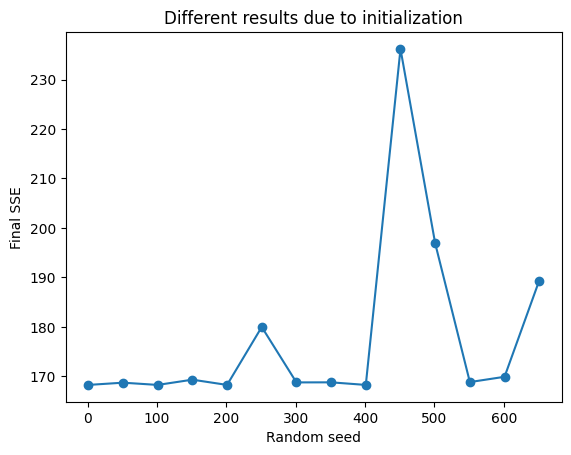

In [27]:
plt.plot(seeds, inertias, marker="o")
plt.xlabel("Random seed")
plt.ylabel("Final SSE")
plt.title("Different results due to initialization")
plt.show()

# 6. Choosing K

K-Means requires the number of clusters **K** to be defined in advance.

**How to choose K**

1. **Run K-Means for multiple K values** (e.g. 1 → 10)
2. **Plot inertia (SSE) vs K**
3. Look for the **“elbow” point**
   - Where inertia stops decreasing sharply
   - Adding more clusters gives diminishing improvement

**Key idea**

The **Elbow Method** helps find a balance between:
- Too few clusters → underfitting
- Too many clusters → over-segmentation

In [32]:
# Run K-Means for multiple K

features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = mall_df[features].values

X = StandardScaler().fit_transform(X)

ks = range(1, 11)
inertias = []

for k in ks:
    centroids, labels, history = kmeans_from_scratch(
        X, k=k, random_state=42
    )
    inertias.append(history["inertia"][-1])

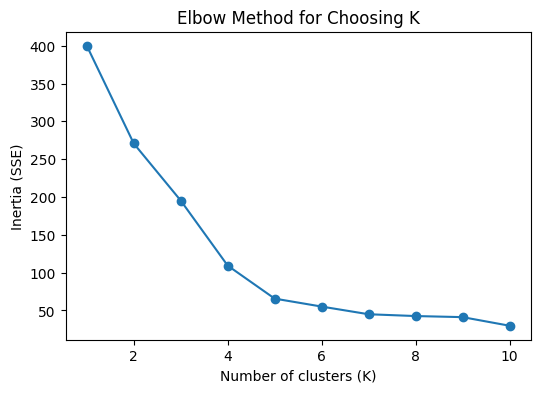

In [33]:
# Plot Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method for Choosing K")
plt.show()

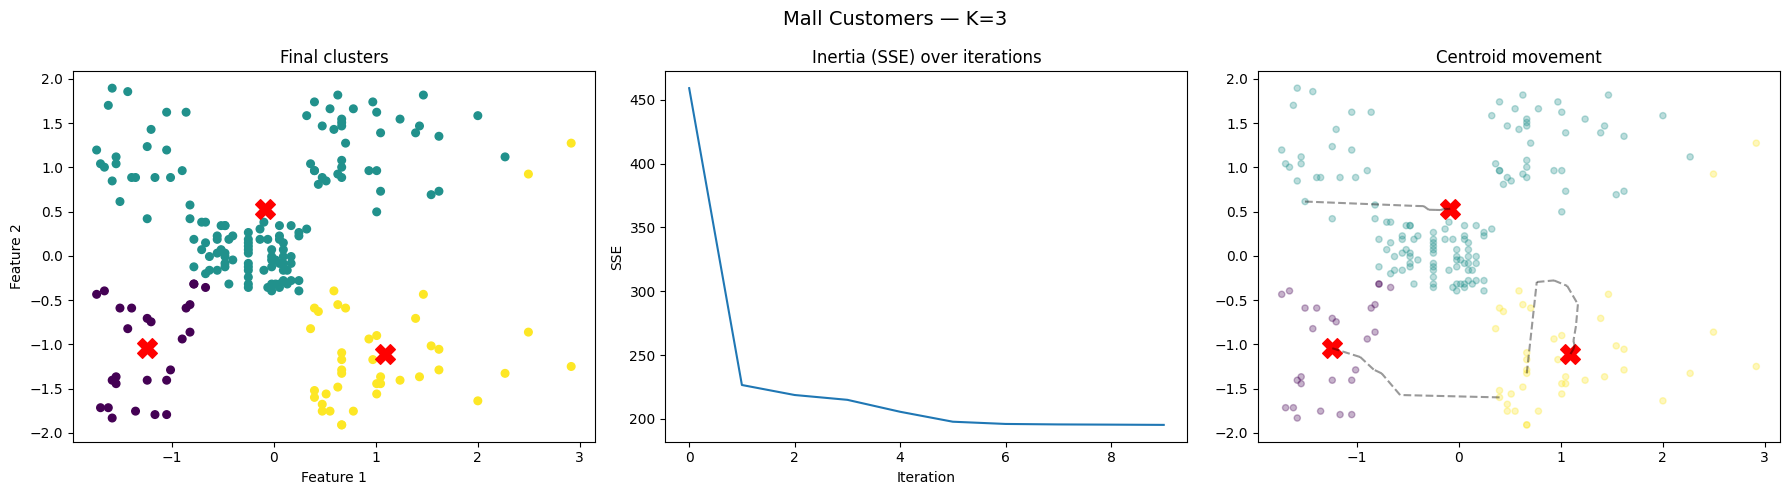

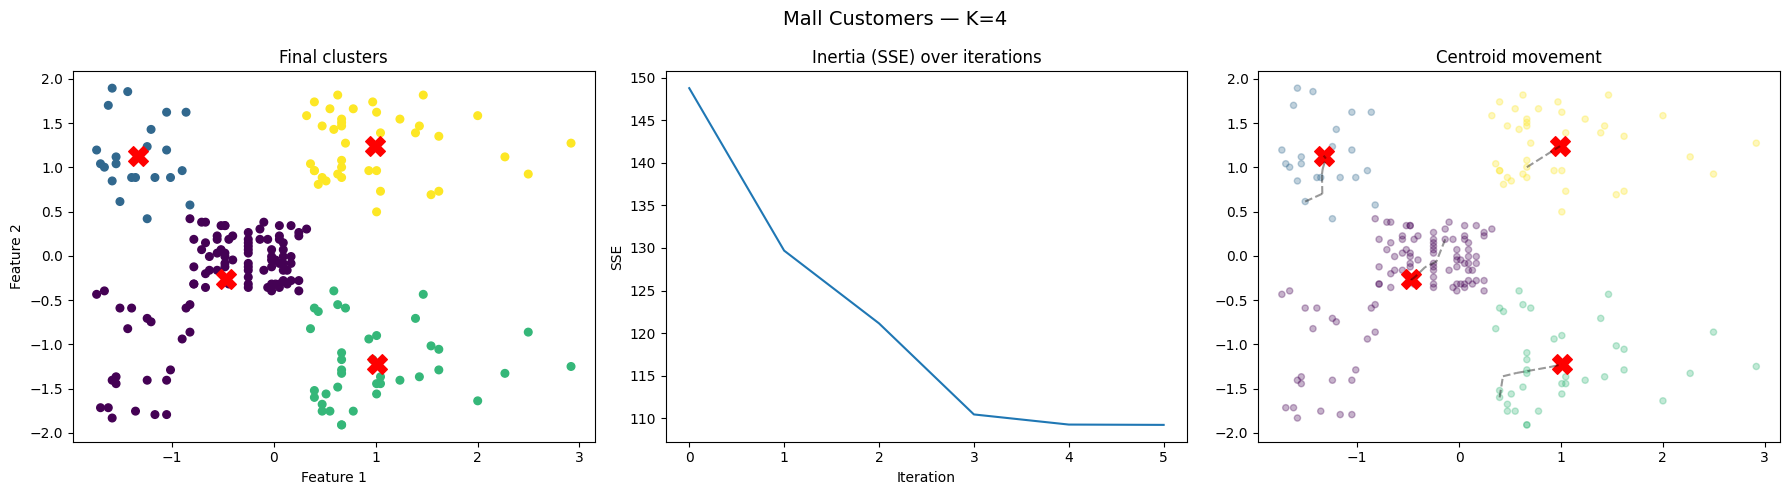

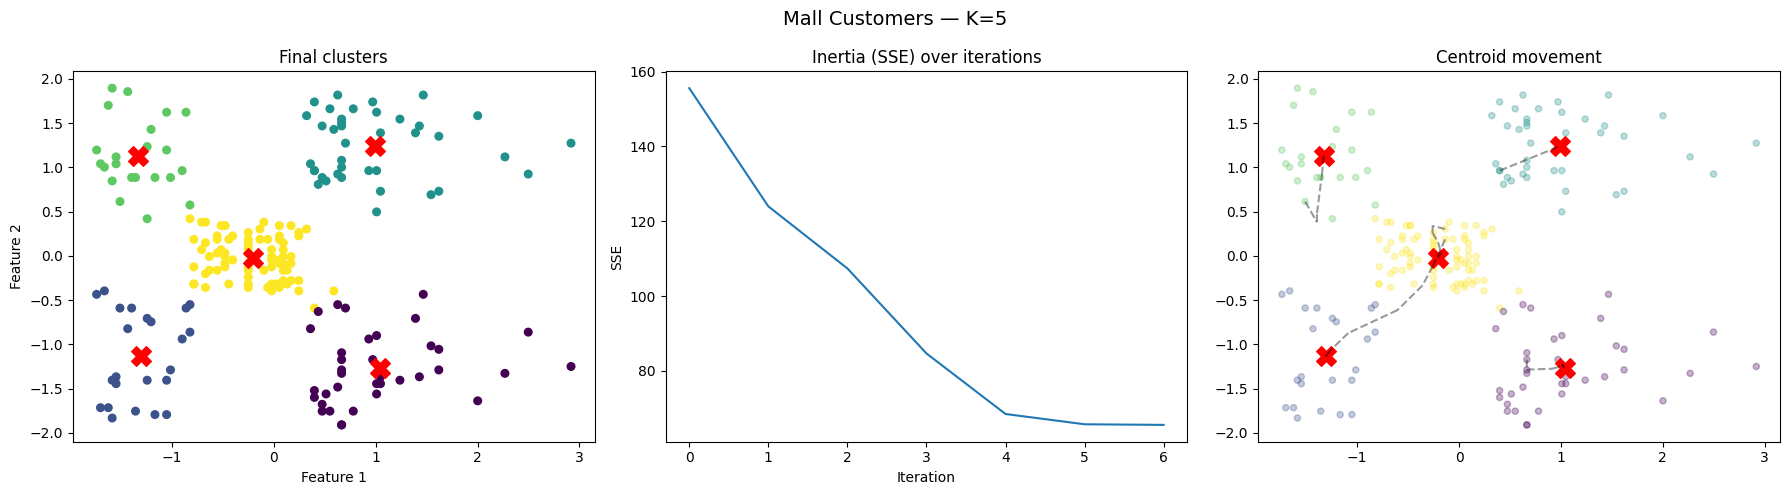

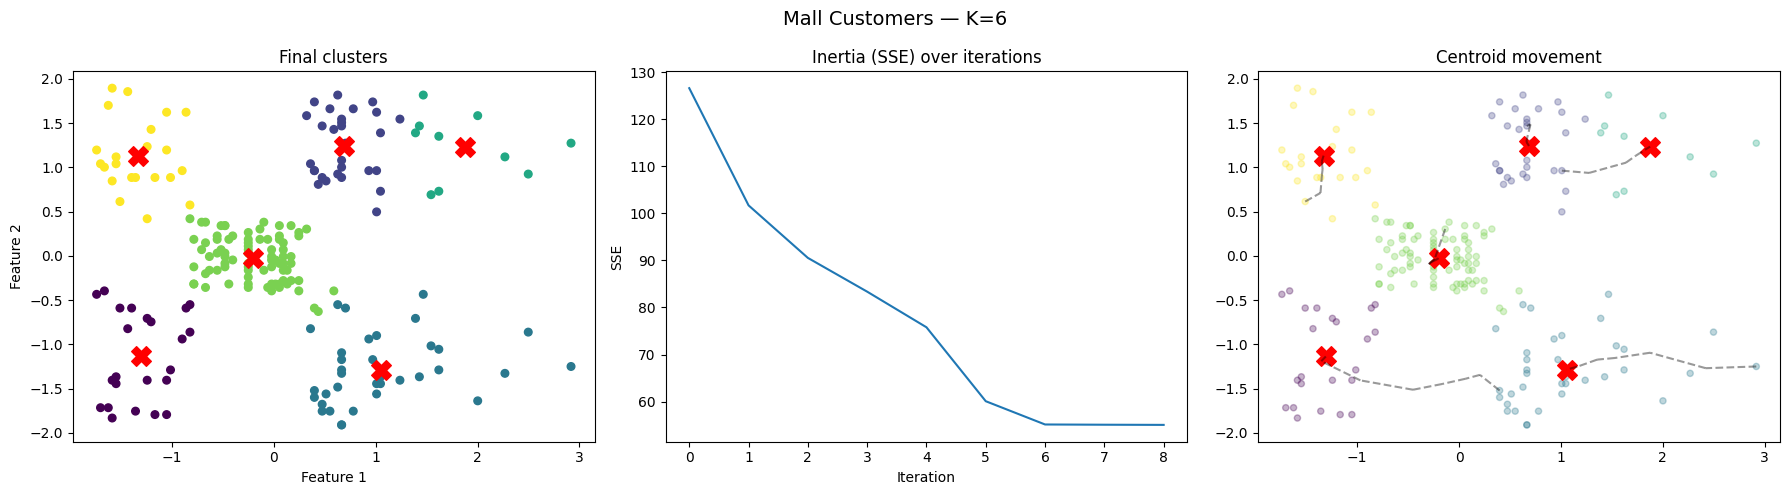

In [35]:
# Visual inspection of selected K values
for k in [3, 4, 5, 6]:
    centroids, labels, history = kmeans_from_scratch(
        X, k=k, random_state=42
    )

    plot_kmeans_result(
        X,
        centroids,
        labels,
        history,
        title=f"Mall Customers — K={k}"
    )

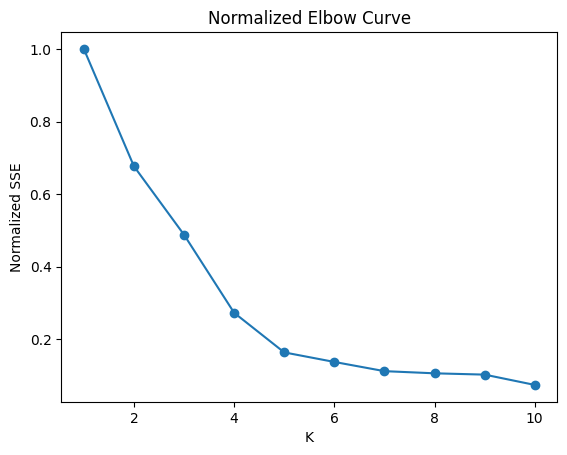

In [37]:
# Normalize elbow values
inertias_norm = np.array(inertias) / inertias[0]

plt.plot(list(ks), inertias_norm, marker="o")
plt.xlabel("K")
plt.ylabel("Normalized SSE")
plt.title("Normalized Elbow Curve")
plt.show()

# 7. Failure cases (synthetic data)

K-Means works well only for:
- spherical clusters
- similar density clusters

It fails on:
- non-linear structures (moons, circles)
- non-convex shapes

In such cases, algorithms like DBSCAN or spectral clustering are more suitable.

In [38]:
from sklearn.datasets import make_moons, make_blobs, make_circles

# Dataset 1: Moons (non-linear structure)
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

# Dataset 2: Circles
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
X_circles = StandardScaler().fit_transform(X_circles)

# Dataset 3: Blobs (baseline — K-Means works well here)
X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)
X_blobs = StandardScaler().fit_transform(X_blobs)

In [39]:
# Run K-Means on all datasets
datasets = {
    "Moons": X_moons,
    "Circles": X_circles,
    "Blobs": X_blobs
}

results = {}

for name, X in datasets.items():
    centroids, labels, history = kmeans_from_scratch(X, k=2, random_state=42)
    results[name] = (X, centroids, labels, history)

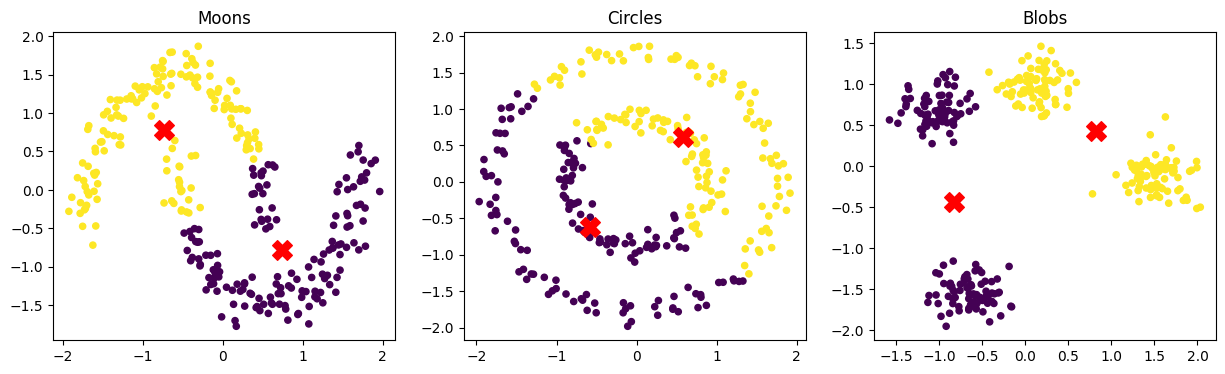

In [40]:
# Visualize failures vs success
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (X, centroids, labels, history)) in zip(axes, results.items()):
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=20)
    ax.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X")
    ax.set_title(name)

plt.show()

# 8. Outliers sensitivity

K-Means is highly sensitive to outliers.

Even a few extreme points can:
- distort centroids
- shift cluster boundaries
- degrade overall clustering quality

This happens because K-Means minimizes squared distances, which heavily penalizes outliers.

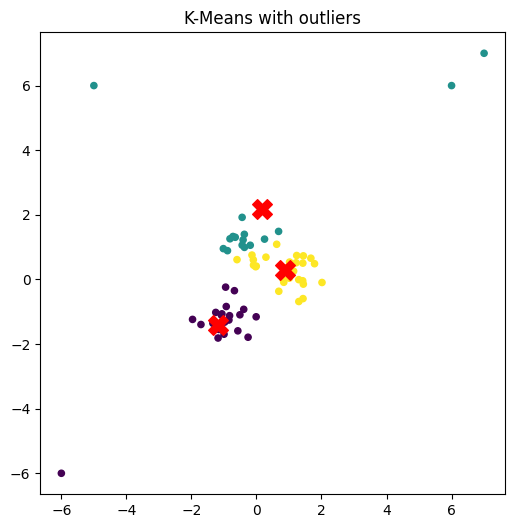

In [51]:
from sklearn.datasets import make_blobs

# Create simple blob data
X, _ = make_blobs(n_samples=60, centers=3, cluster_std=2.65, random_state=42)
X = StandardScaler().fit_transform(X)

# Add outliers
outliers = np.array([
    [6, 6],
    [7, 7],
    [-6, -6],
    [-5, 6]
])

X_out = np.vstack([X, outliers])

# Run K-Means
centroids, labels, history = kmeans_from_scratch(
    X_out, k=3, random_state=42
)

# Visualize impact
plt.figure(figsize=(6, 6))
plt.scatter(X_out[:, 0], X_out[:, 1], c=labels, s=20)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X")
plt.title("K-Means with outliers")
plt.show()


# 9. Feature noise

K-Means is sensitive to irrelevant features.

Adding noise dimensions:
- distorts distance calculations
- weakens meaningful structure
- reduces clustering quality

Feature selection or dimensionality reduction (e.g., PCA) is often necessary before clustering.

In [63]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Create clean dataset
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2, random_state=42)
X = StandardScaler().fit_transform(X)

# Add noisy (irrelevant) features
np.random.seed(42)
noise = np.random.normal(-1, 1, size=(X.shape[0], 5))  # 5 noise features
X_noisy = np.hstack([X, noise])

# Run K-Means on clean vs noisy data
centroids_clean, labels_clean, history_clean = kmeans_from_scratch(
    X, k=3, random_state=42
)

centroids_noisy, labels_noisy, history_noisy = kmeans_from_scratch(
    X_noisy, k=3, random_state=42
)

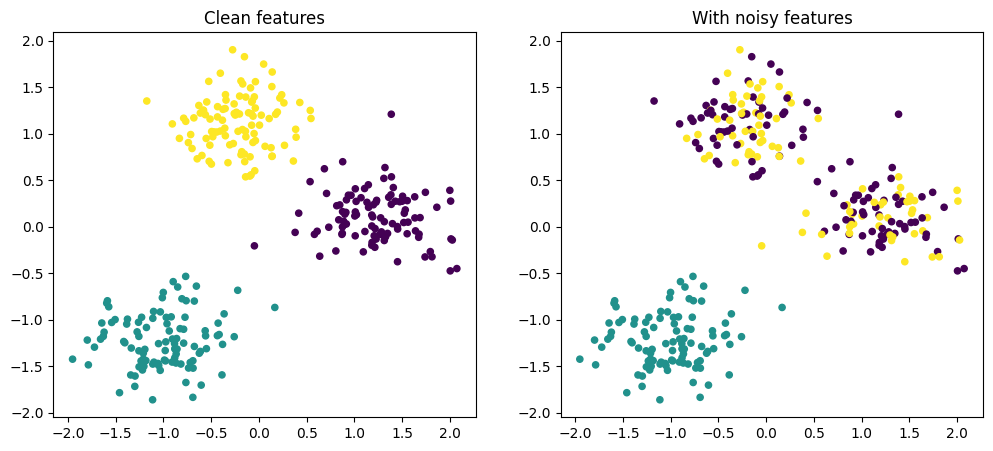

In [64]:
# Compare visually (project back to 2D)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_clean, s=20)
axes[0].set_title("Clean features")

axes[1].scatter(X[:, 0], X[:, 1], c=labels_noisy, s=20)
axes[1].set_title("With noisy features")

plt.show()

# 10. K-Median vs. K-Means

K-Means uses the **mean** as cluster center, while K-Median uses the **median**.

**Key difference**

- **K-Means** → minimizes squared Euclidean distance (L2), sensitive to outliers  
- **K-Median** → minimizes absolute distance (L1), more robust to outliers

**Practical effect**

- K-Means → smoother, geometry-driven clusters  
- K-Median → more stable clusters, less influenced by extreme values

**Takeaway**

K-Median is a more **robust alternative to K-Means**, especially when data contains outliers or skewed distributions.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

features = ["Annual Income (k$)", "Spending Score (1-100)"]

X = mall_df[features].values
X = StandardScaler().fit_transform(X)

# K-Means (baseline)
centroids_km, labels_km, history_km = kmeans_from_scratch(
    X, k=5, random_state=42
)

In [66]:
from mlpeople.models.clustering.kmedian import kmedian

# Run K-Median
centroids_kmed, labels_kmed = kmedian(X, k=5, random_state=42)


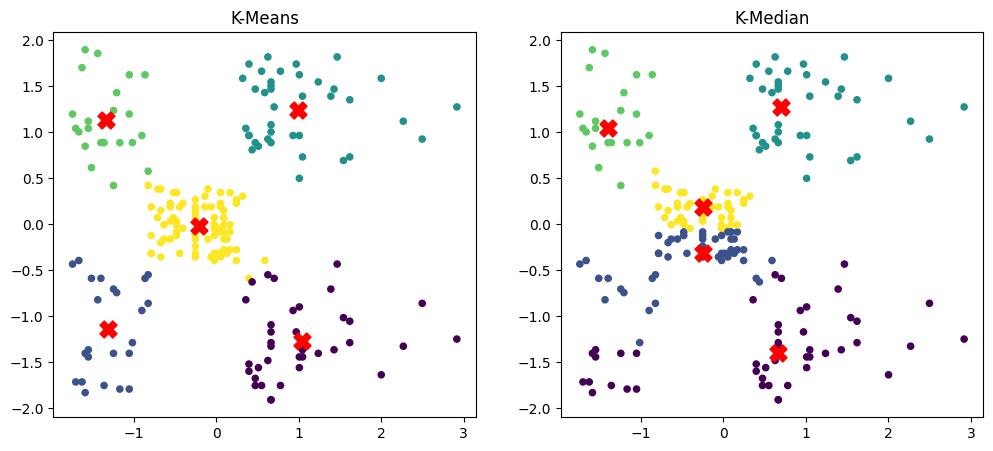

In [67]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means
axes[0].scatter(X[:, 0], X[:, 1], c=labels_km, s=20)
axes[0].scatter(centroids_km[:, 0], centroids_km[:, 1], c="red", s=150, marker="X")
axes[0].set_title("K-Means")

# K-Median
axes[1].scatter(X[:, 0], X[:, 1], c=labels_kmed, s=20)
axes[1].scatter(centroids_kmed[:, 0], centroids_kmed[:, 1], c="red", s=150, marker="X")
axes[1].set_title("K-Median")

plt.show()

**K-Means**
 - Centroids are pulled toward “dense gravity centers”
 - Slight influence from extreme values
 - More “round / balanced” clusters


**K-Median**
 - Centers stay more stable inside dense regions
 - Less affected by spread or extremes
 - Slightly different cluster boundaries in border areas